# 01 — Data Profiling
**El primer contacto con un dataset nuevo.**

Antes de cualquier análisis o modelo, necesitás entender la estructura básica del dato:
qué hay, cuánto hay, de qué tipo es y qué tan confiable es.

## Checklist de primer contacto
1. **Shape** — cuántas filas y columnas
2. **Tipos** — numérico, categórico, datetime, booleano
3. **Memoria** — tamaño en RAM
4. **Missing values** — cuánto falta y dónde
5. **Duplicados** — filas idénticas o casi idénticas
6. **Estadísticas descriptivas** — rango, media, dispersión
7. **Cardinalidad** — valores únicos por columna
8. **Consistencia** — tipos que deberían ser distintos, valores imposibles

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'legend.frameon': False,
    'font.family': 'Optima'
})
np.random.seed(42)

# Dataset: transacciones de e-commerce (se reutiliza en todos los notebooks)
# Simula un dataset realista con problemas típicos: missings, outliers, tipos mixtos
n = 5000
rng = np.random.default_rng(42)

user_ids   = rng.integers(1000, 9999, n)
order_ids  = np.arange(100_000, 100_000 + n)
dates      = pd.date_range('2023-01-01', periods=n, freq='2h') + pd.to_timedelta(rng.integers(0, 120, n), unit='m')
categories = rng.choice(['Electronics', 'Clothing', 'Home', 'Sports', 'Books', 'Beauty'], n,
                         p=[0.25, 0.22, 0.18, 0.15, 0.12, 0.08])
countries  = rng.choice(['US', 'UK', 'DE', 'MX', 'BR', 'FR', 'CA'], n,
                         p=[0.35, 0.15, 0.12, 0.10, 0.10, 0.10, 0.08])
channels   = rng.choice(['organic', 'paid', 'email', 'direct', 'affiliate'], n,
                         p=[0.30, 0.25, 0.20, 0.15, 0.10])
devices    = rng.choice(['mobile', 'desktop', 'tablet'], n, p=[0.55, 0.35, 0.10])

price      = np.where(categories == 'Electronics', rng.lognormal(4.5, 0.8, n),
             np.where(categories == 'Clothing',    rng.lognormal(3.5, 0.6, n),
                                                   rng.lognormal(3.2, 0.7, n))).round(2)
qty        = rng.integers(1, 8, n)
discount   = np.where(rng.uniform(0,1,n) < 0.3, rng.uniform(0.05, 0.40, n), 0.0).round(2)
revenue    = (price * qty * (1 - discount)).round(2)

# Inyectar problemas realistas
# Missings
miss_idx = rng.choice(n, size=int(n * 0.08), replace=False)
discount_arr = discount.copy().astype(object); discount_arr[miss_idx[:200]] = np.nan
country_arr  = np.array(countries, dtype=object); country_arr[miss_idx[200:350]] = np.nan
rating_raw   = rng.choice([1,2,3,4,5], n, p=[0.05,0.10,0.20,0.40,0.25]).astype(float)
rating_raw[miss_idx[350:]] = np.nan

# Outliers en revenue
outlier_idx = rng.choice(n, size=15, replace=False)
revenue[outlier_idx] = rng.uniform(5000, 15000, 15)

# Duplicados
dup_rows = rng.choice(n, size=30, replace=False)

df = pd.DataFrame({
    'order_id':   order_ids,
    'user_id':    user_ids,
    'date':       dates,
    'category':   categories,
    'country':    country_arr,
    'channel':    channels,
    'device':     devices,
    'price':      price,
    'quantity':   qty,
    'discount':   discount_arr,
    'revenue':    revenue,
    'rating':     rating_raw,
})

# Agregar filas duplicadas
df = pd.concat([df, df.iloc[dup_rows]], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Dataset generado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

Dataset generado: 5,030 filas × 12 columnas


## 1 — Shape, tipos y memoria

In [2]:
print(f'Shape:   {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n')

# Tipos de datos
type_summary = pd.DataFrame({
    'dtype':    df.dtypes,
    'n_unique': df.nunique(),
    'n_null':   df.isnull().sum(),
    'pct_null': (df.isnull().mean() * 100).round(2),
    'sample':   [str(df[c].dropna().iloc[0]) if df[c].notna().any() else 'N/A' for c in df.columns],
})
print(type_summary.to_string())

Shape:   5,030 filas × 12 columnas
Memoria: 0.68 MB

                   dtype  n_unique  n_null  pct_null               sample
order_id           int64      5000       0      0.00               102525
user_id            int64      3825       0      0.00                 3915
date      datetime64[us]      5000       0      0.00  2023-07-30 10:10:00
category             str         6       0      0.00          Electronics
country              str         7     152      3.02                   US
channel              str         5       0      0.00                 paid
device               str         3       0      0.00              desktop
price            float64      3886       0      0.00                81.04
quantity           int64         7       0      0.00                    2
discount          object        37     201      4.00                  0.0
revenue          float64      4592       0      0.00               162.08
rating           float64         5      50      0.99       

## 2 — Estadísticas descriptivas

In [3]:
# Numéricas
print('── Numéricas ─────────────────────────────────')
print(df.select_dtypes('number').describe().T.round(2).to_string())

# Categóricas (pandas 3: pasar 'str' en lugar de 'object')
print('\n── Categóricas ───────────────────────────────')
print(df.select_dtypes(include=['object', 'str']).describe().to_string())

# Datetime (datetime_is_numeric fue removido en pandas 2.0)
print('\n── Datetime ──────────────────────────────────')
dt_cols = df.select_dtypes('datetime')
if not dt_cols.empty:
    print(dt_cols.describe().to_string())
else:
    print('Sin columnas datetime.')

── Numéricas ─────────────────────────────────
           count       mean      std        min        25%        50%        75%        max
order_id  5030.0  102501.73  1443.56  100000.00  101252.25  102504.50  103752.75  104999.00
user_id   5030.0    5485.00  2604.97    1004.00    3221.50    5445.00    7763.50    9996.00
price     5030.0      57.30    77.69       1.98      19.88      33.70      62.83    1713.01
quantity  5030.0       4.02     2.02       1.00       2.00       4.00       6.00       7.00
revenue   5030.0     247.06   674.85       1.91      54.90     112.84     236.49   13732.12
rating    4980.0       3.69     1.11       1.00       3.00       4.00       4.00       5.00

── Categóricas ───────────────────────────────
           category country  channel  device  discount
count          5030    4878     5030    5030    4829.0
unique            6       7        5       3      37.0
top     Electronics      US  organic  mobile       0.0
freq           1264    1701     1497    2

## 3 — Missing values: mapa visual

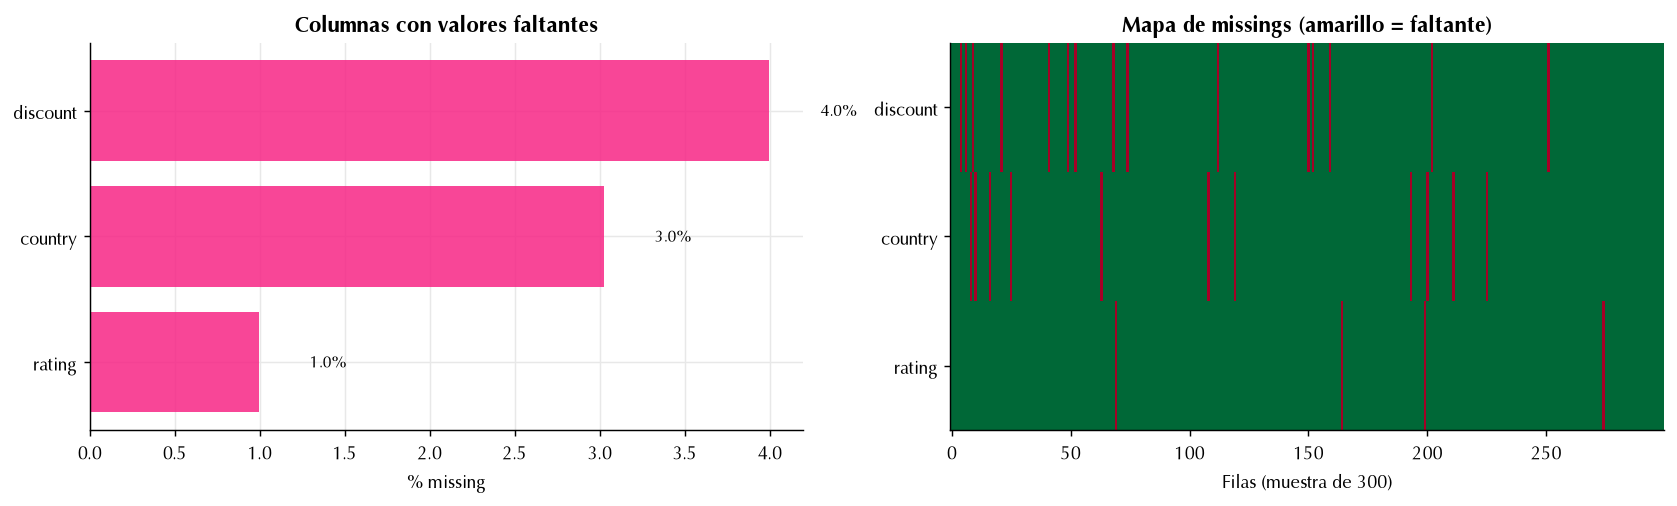

Co-ocurrencia de missings (% de filas donde ambos faltan):
          discount  country  rating
discount      0.04     0.00    0.00
country       0.00     0.03    0.00
rating        0.00     0.00    0.01


In [4]:
miss = df.isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Barras de % missing
axes[0].barh(miss.index[::-1], miss.values[::-1] * 100, color='#f72585', alpha=0.85)
axes[0].set_xlabel('% missing')
axes[0].set_title('Columnas con valores faltantes')
for i, v in enumerate(miss.values[::-1]):
    axes[0].text(v * 100 + 0.3, i, f'{v:.1%}', va='center', fontsize=9)

# Heatmap de missingness (muestra 300 filas para visualizar patrones)
sample = df[miss.index].isnull().sample(300, random_state=0)
axes[1].imshow(sample.T.values, aspect='auto', cmap='RdYlGn_r', interpolation='none')
axes[1].set_yticks(range(len(miss.index)))
axes[1].set_yticklabels(miss.index)
axes[1].set_xlabel('Filas (muestra de 300)')
axes[1].set_title('Mapa de missings (amarillo = faltante)')
axes[1].grid(False)

plt.tight_layout()
plt.show()

# Co-ocurrencia de missings
print('Co-ocurrencia de missings (% de filas donde ambos faltan):')
miss_cols = miss.index.tolist()
cooc = pd.DataFrame(index=miss_cols, columns=miss_cols, dtype=float)
for c1 in miss_cols:
    for c2 in miss_cols:
        cooc.loc[c1, c2] = (df[c1].isnull() & df[c2].isnull()).mean()
print(cooc.round(3).to_string())

## 4 — Duplicados

In [5]:
n_dup_full = df.duplicated().sum()
n_dup_key  = df.duplicated(subset=['order_id']).sum()

print(f'Filas duplicadas (todas las columnas): {n_dup_full} ({n_dup_full/len(df):.1%})')
print(f'order_id duplicados:                   {n_dup_key} ({n_dup_key/len(df):.1%})')

# Mostrar ejemplos
if n_dup_full > 0:
    print('\nEjemplos de filas duplicadas:')
    dup_mask = df.duplicated(keep=False)
    print(df[dup_mask].head(4).to_string())

Filas duplicadas (todas las columnas): 30 (0.6%)
order_id duplicados:                   30 (0.6%)

Ejemplos de filas duplicadas:
     order_id  user_id                date  category country    channel   device  price  quantity discount      revenue  rating
118    104983     4618 2024-02-20 07:42:00      Home      MX       paid   mobile  25.34         7      0.4   106.430000     1.0
129    101770     4041 2023-05-28 13:07:00  Clothing      UK  affiliate   tablet  28.44         4      0.0   113.760000     4.0
213    102507     6575 2023-07-28 23:30:00     Books      DE    organic  desktop  42.31         6     0.09  7721.191139     5.0
237    104076     9818 2023-12-06 17:24:00     Books      US       paid  desktop   7.51         3      0.0    22.530000     4.0


## 5 — Cardinalidad y valores únicos

In [6]:
cat_cols = df.select_dtypes('object').columns

for col in cat_cols:
    vc = df[col].value_counts(dropna=False)
    top3 = ', '.join([f'{k}({v})' for k, v in vc.head(3).items()])
    print(f'{col:<12} n_unique={df[col].nunique():>4}  top3: {top3}')

category     n_unique=   6  top3: Electronics(1264), Clothing(1102), Home(913)
country      n_unique=   7  top3: US(1701), UK(715), DE(589)
channel      n_unique=   5  top3: organic(1497), paid(1214), email(1024)
device       n_unique=   3  top3: mobile(2785), desktop(1757), tablet(488)
discount     n_unique=  37  top3: 0.0(3376), nan(201), 0.06(54)


/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_17062/3691670831.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes('object').columns


## 6 — Función de profiling reutilizable

In [7]:
def quick_profile(df: pd.DataFrame) -> pd.DataFrame:
    """Genera tabla de resumen para cualquier DataFrame."""
    profile = pd.DataFrame(index=df.columns)
    profile['dtype']     = df.dtypes
    profile['n_unique']  = df.nunique()
    profile['n_null']    = df.isnull().sum()
    profile['pct_null']  = (df.isnull().mean() * 100).round(1)
    profile['n_dup']     = df.apply(lambda s: s.duplicated().sum())

    num_cols = df.select_dtypes('number').columns
    profile.loc[num_cols, 'min']  = df[num_cols].min().round(2)
    profile.loc[num_cols, 'max']  = df[num_cols].max().round(2)
    profile.loc[num_cols, 'mean'] = df[num_cols].mean().round(2)
    profile.loc[num_cols, 'std']  = df[num_cols].std().round(2)

    cat_cols = df.select_dtypes('object').columns
    profile.loc[cat_cols, 'top_value'] = df[cat_cols].mode().iloc[0]
    return profile

print(quick_profile(df).to_string())

# Guardar el dataset limpio de duplicados para los siguientes notebooks
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f'\nDataset sin duplicados: {df_clean.shape[0]:,} filas')

                   dtype  n_unique  n_null  pct_null  n_dup        min        max       mean      std    top_value
order_id           int64      5000       0       0.0     30  100000.00  104999.00  102501.73  1443.56          NaN
user_id            int64      3825       0       0.0   1205    1004.00    9996.00    5485.00  2604.97          NaN
date      datetime64[us]      5000       0       0.0     30        NaN        NaN        NaN      NaN          NaN
category             str         6       0       0.0   5024        NaN        NaN        NaN      NaN  Electronics
country              str         7     152       3.0   5022        NaN        NaN        NaN      NaN           US
channel              str         5       0       0.0   5025        NaN        NaN        NaN      NaN      organic
device               str         3       0       0.0   5027        NaN        NaN        NaN      NaN       mobile
price            float64      3886       0       0.0   1144       1.98    1713.0

/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_17062/2951703613.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes('object').columns


## Resumen

| Check | Qué buscar | Acción |
|---|---|---|
| Shape | Filas y columnas esperadas | Verificar contra fuente original |
| Tipos | `object` donde debería ser `float`, `int` donde debería ser `category` | Castear antes de analizar |
| Missings | % por columna, co-ocurrencia | Ver `05_missing_data.ipynb` |
| Duplicados | Filas idénticas vs. duplicados de clave | `drop_duplicates()` o investigar origen |
| Cardinalidad | Categóricas con miles de valores únicos | Agrupar o usar target encoding |
| Rango | Valores negativos donde no corresponde, fechas futuras | Filtrar o clipear |

**Siguiente:** `02_distributions.ipynb`